# HMM2 — Detección de comportamiento (descanso vs. viaje)

Implementación alternativa del HMM para el objetivo **O3** del TFG. Plan completo en `notebooks/HMM2_plan.md`.

Convención (CLAUDE.md): `0 = migración`, `1 = estacionario`.

**Esta es la versión v2** del notebook. La v1 usaba `log(step_length+1)` + `cos(turning_angle)` + `StandardScaler` + `covariance_type='full'`. Esa configuración **no separó migración de descanso** (el estado "estacionario" tenía mediana de paso 4,5 km, mayor que la del "migración" 3,2 km, persistencia diagonal 0,27 y sin pico estacional). El motivo: `log` + `StandardScaler` diluyen la bimodalidad natural de `step_length`, que era precisamente la señal más fuerte del problema. Detalles en `HMM2_plan.md`, sección "Lección aprendida".

**v2 (este notebook)** mantiene los aciertos de la v1 y corrige las decisiones de transformación:

1. Pasa `lengths=` con el tamaño de cada `trayectoria_id` para no aprender transiciones espurias entre secuencias distintas.
2. Solo features de movimiento puro: `step_length` (km, **bruto**) y `cos(turning_angle)`. Sin vegetación.
3. **Sin `StandardScaler`**: la varianza enorme de `step_length` debe dominar la verosimilitud Gaussian para que los dos modos (descanso ~4 km, migración ~120 km) se separen.
4. `covariance_type='diag'` (con escalas dispares, full es inestable).
5. 15 inicializaciones aleatorias; se conserva la de mayor log-likelihood.
6. Etiquetado 0/1 automático por `means_` (robusto al `random_state`).
7. Validación: matriz de transición, duración por estado, patrón estacional.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM

plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

## 1. Carga del CSV limpio

Entrada: `data/processed/aves_procesado_markov.csv`, producido por `dataExploration1.ipynb` (1 fila/(ave, día) hacia las 14h, segmentos continuos de ≥4 días por `trayectoria_id`).

In [2]:
df = pd.read_csv('../data/processed/aves_procesado_markov.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['trayectoria_id', 'date']).reset_index(drop=True)

print(f'Filas: {len(df):,}')
print(f'Aves únicas: {df["animal_id"].nunique()}')
print(f'Trayectorias: {df["trayectoria_id"].nunique()}')
print(f'Rango temporal: {df["date"].min().date()} → {df["date"].max().date()}')
df.head()

Filas: 22,041
Aves únicas: 117
Trayectorias: 480
Rango temporal: 2009-05-25 → 2015-08-23


,animal_id,date,hora,lon,lat,veg_low,veg_high,trayectoria_id
0,91732A,2010-04-18,14,32.6790,29.1823,0.0032,0.0001,91732A_Seg10
1,91732A,2010-04-19,14,32.5083,29.8573,0.0114,0.0006,91732A_Seg10
2,91732A,2010-04-20,14,32.4677,29.9302,0.0131,0.0007,91732A_Seg10
3,91732A,2010-04-21,14,32.4933,29.8072,0.0112,0.0006,91732A_Seg10
4,91732A,2010-04-22,14,32.4782,29.9287,0.0128,0.0007,91732A_Seg10


## 2. Features de movimiento

Para cada `trayectoria_id`:

- `step_length` = haversine entre día t y día t+1, en km.
- `bearing` = great-circle initial bearing entre los mismos dos puntos, en grados [0, 360).
- `turning_angle` = cambio de rumbo entre pasos consecutivos, normalizado a [-π, π] en radianes.

Las funciones `haversine_km` y `calculate_bearing` son las mismas que en `HMM.ipynb` — están geométricamente correctas.

In [3]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Distancia haversine entre dos puntos (lat, lon) en grados, en km."""
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2) ** 2
    return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1 - a))


def calculate_bearing(lat1, lon1, lat2, lon2):
    """Rumbo great-circle inicial en grados [0, 360); 0=norte, sentido horario."""
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dlambda = np.radians(lon2 - lon1)
    y = np.sin(dlambda) * np.cos(phi2)
    x = np.cos(phi1) * np.sin(phi2) - np.sin(phi1) * np.cos(phi2) * np.cos(dlambda)
    return (np.degrees(np.arctan2(y, x)) + 360) % 360

In [4]:
df['next_lat'] = df.groupby('trayectoria_id')['lat'].shift(-1)
df['next_lon'] = df.groupby('trayectoria_id')['lon'].shift(-1)

df['step_length'] = haversine_km(df['lat'], df['lon'], df['next_lat'], df['next_lon'])
df['bearing'] = calculate_bearing(df['lat'], df['lon'], df['next_lat'], df['next_lon'])

delta_bearing = df.groupby('trayectoria_id')['bearing'].diff()
df['turning_angle'] = np.arctan2(
    np.sin(np.radians(delta_bearing)),
    np.cos(np.radians(delta_bearing)),
)

print('NaNs por columna (esperados: última fila/trayectoria sin step, primera sin turning):')
print(df[['step_length', 'bearing', 'turning_angle']].isna().sum())

NaNs por columna (esperados: última fila/trayectoria sin step, primera sin turning):
step_length      480
bearing          480
turning_angle    960
dtype: int64


In [5]:
# Quitar filas sin step_length (último día de cada trayectoria) y sin turning_angle (primer día).
# Mantenemos el orden por (trayectoria_id, date) para que `lengths=` luego cuadre.
df_hmm = df.dropna(subset=['step_length', 'turning_angle']).reset_index(drop=True)
print(f'Filas tras limpieza: {len(df_hmm):,} (eliminadas {len(df) - len(df_hmm)})')
df_hmm[['animal_id', 'trayectoria_id', 'date', 'step_length', 'bearing', 'turning_angle']].head()

Filas tras limpieza: 21,081 (eliminadas 960)


,animal_id,trayectoria_id,date,step_length,bearing,turning_angle
0,91732A,91732A_Seg10,2010-04-19,8.9980,334.1859,-0.2347
1,91732A,91732A_Seg10,2010-04-20,13.8990,169.7393,-2.8701
2,91732A,91732A_Seg10,2010-04-21,13.5890,353.8284,-3.0702
3,91732A,91732A_Seg10,2010-04-22,14.1345,186.9951,-2.9118
4,91732A,91732A_Seg10,2010-04-23,24.3664,5.8214,3.1211


## 3. Matriz de observaciones

Decisión de diseño tras un experimento fallido (ver `HMM2_plan.md`, sección "Lección aprendida"): **dejamos `step_length` en su escala natural en km** y **no aplicamos `StandardScaler`**. La distribución de `step_length` es claramente bimodal en este dataset (pico 0–5 km de descanso, cola 50–200+ km de migración) y esa varianza enorme es precisamente la señal que el HMM necesita para separar los dos modos. Aplicar log + escalado diluye esa bimodalidad y el modelo se latcha a otro eje (lo que pasó en v1).

- `step_length` (km, raw): la varianza enorme domina la verosimilitud Gaussian → fuerza al modelo a separar por velocidad.
- `cos_turn = cos(turning_angle)` ∈ [-1, 1]: convierte la variable circular en un real, vale 1 cuando el ave sigue recta y -1 cuando se da media vuelta. Actúa como feature secundaria que refina ligeramente la separación.


In [6]:
df_hmm['cos_turn'] = np.cos(df_hmm['turning_angle'])

# X tiene step_length en km (sin transformar) y cos(turning_angle) en [-1, 1].
# NO aplicamos StandardScaler: queremos que la varianza enorme de step_length
# domine la verosimilitud Gaussian para que el HMM separe los modos por velocidad.
X = df_hmm[['step_length', 'cos_turn']].values

print(f'X.shape = {X.shape}')
print('Estadísticas (sin escalar — varianzas dispares a propósito):')
print(pd.DataFrame({
    'mean': X.mean(axis=0),
    'std': X.std(axis=0),
    'min': X.min(axis=0),
    'max': X.max(axis=0),
}, index=['step_length (km)', 'cos_turn']))

X.shape = (21081, 2)
Estadísticas (sin escalar — varianzas dispares a propósito):
                    mean      std     min       max
step_length (km) 30.7354 109.1007  0.0000 1487.8530
cos_turn         -0.1941   0.7842 -1.0000    1.0000


## 4. Ajuste del HMM

- `GaussianHMM(n_components=2, covariance_type='diag', n_iter=200, tol=1e-4)`. Con escalas dispares entre features, `diag` es más estable que `full`.
- `lengths=` con el tamaño de cada `trayectoria_id` — **paso crítico**: sin esto, `hmmlearn` modela las 21k observaciones como una sola cadena y la matriz de transición incluye saltos espurios entre el final de una trayectoria y el inicio de otra (incluso entre aves distintas).
- 15 inicializaciones con `random_state ∈ {0, ..., 14}`; nos quedamos con la de mayor log-likelihood. Mitiga óptimos locales del EM.


In [7]:
# `lengths` debe estar en el mismo orden que las filas de X.
# df_hmm está ordenado por (trayectoria_id, date) y groupby con sort=False respeta ese orden.
lengths = df_hmm.groupby('trayectoria_id', sort=False).size().values
assert lengths.sum() == len(X), 'lengths no suma a len(X) — orden incorrecto'
print(f'Trayectorias: {len(lengths)} | Total observaciones: {lengths.sum():,}')
print(f'Tamaño medio de trayectoria: {lengths.mean():.1f} días (mín {lengths.min()}, máx {lengths.max()})')

Trayectorias: 480 | Total observaciones: 21,081
Tamaño medio de trayectoria: 43.9 días (mín 2, máx 1253)


In [8]:
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=UserWarning)

best_score = -np.inf
best_model = None
best_seed = None
all_scores = []

for seed in range(15):
    m = GaussianHMM(
        n_components=2,
        covariance_type='diag',
        n_iter=200,
        tol=1e-4,
        random_state=seed,
    )
    m.fit(X, lengths=lengths)
    s = m.score(X, lengths=lengths)
    all_scores.append(s)
    if s > best_score:
        best_score = s
        best_model = m
        best_seed = seed

print(f'Mejor inicialización: seed={best_seed}, log-likelihood={best_score:,.1f}')
print(f'Convergió: {best_model.monitor_.converged} en {best_model.monitor_.iter} iteraciones')
print(f'Rango de log-likelihoods: [{min(all_scores):,.1f}, {max(all_scores):,.1f}]')

Mejor inicialización: seed=5, log-likelihood=-113,068.9
Convergió: True en 69 iteraciones
Rango de log-likelihoods: [-113,068.9, -113,068.9]


## 5. Asignación automática de etiquetas 0/1

`means_[k, 0]` es la media de `step_length` (en km) en el estado k. El estado con media mayor → más movimiento → migración (etiqueta `0`); el otro → estacionario (etiqueta `1`). Asignación invariante al `random_state`.


In [9]:
state_means_step = best_model.means_[:, 0]  # km, sin escalar
print(f'Medias de step_length por estado interno (km): {state_means_step.round(2)}')

migration_state = int(np.argmax(state_means_step))
stationary_state = 1 - migration_state
print(f'Estado interno {migration_state} → migración (etiqueta 0)')
print(f'Estado interno {stationary_state} → estacionario (etiqueta 1)')

raw_states = best_model.predict(X, lengths=lengths)
df_hmm['estado_hmm'] = np.where(raw_states == migration_state, 0, 1)

# Permutar transmat_ y means_ para que el índice 0 sea migración, 1 estacionario.
perm = [migration_state, stationary_state]
transmat_remapped = best_model.transmat_[perm][:, perm]
means_remapped = best_model.means_[perm]

print('\nDistribución de estados:')
print(df_hmm['estado_hmm'].value_counts(normalize=True).rename(
    index={0: 'migración', 1: 'estacionario'},
).round(4))

Medias de step_length por estado interno (km): [  4.07 124.38]
Estado interno 1 → migración (etiqueta 0)
Estado interno 0 → estacionario (etiqueta 1)

Distribución de estados:
estado_hmm
estacionario   0.7877
migración      0.2123
Name: proportion, dtype: float64


## 6. Guardar `hmm2.csv`

Escribimos un archivo nuevo (`hmm2.csv`) en lugar de sobrescribir `hmm.csv`, para poder comparar HMM1 y HMM2 lado a lado.

In [10]:
out_cols = [
    'animal_id', 'date', 'hora', 'lon', 'lat',
    'veg_low', 'veg_high', 'trayectoria_id',
    'step_length', 'bearing', 'turning_angle', 'estado_hmm',
]
out = df_hmm[out_cols].copy()
out['date'] = out['date'].dt.strftime('%Y-%m-%d')
out_path = '../data/processed/hmm2.csv'
out.to_csv(out_path, index=False)
print(f'Guardado: {out_path}')
print(f'Filas: {len(out):,} | Columnas: {len(out.columns)}')
out.head()

Guardado: ../data/processed/hmm2.csv
Filas: 21,081 | Columnas: 12


,animal_id,date,hora,lon,lat,veg_low,veg_high,trayectoria_id,step_length,bearing,turning_angle,estado_hmm
0,91732A,2010-04-19,14,32.5083,29.8573,0.0114,0.0006,91732A_Seg10,8.9980,334.1859,-0.2347,1
1,91732A,2010-04-20,14,32.4677,29.9302,0.0131,0.0007,91732A_Seg10,13.8990,169.7393,-2.8701,1
2,91732A,2010-04-21,14,32.4933,29.8072,0.0112,0.0006,91732A_Seg10,13.5890,353.8284,-3.0702,1
3,91732A,2010-04-22,14,32.4782,29.9287,0.0128,0.0007,91732A_Seg10,14.1345,186.9951,-2.9118,1
4,91732A,2010-04-23,14,32.4603,29.8025,0.0119,0.0007,91732A_Seg10,24.3664,5.8214,3.1211,0


## 7. Validación: coherencia del comportamiento detectado

Reportamos las métricas que acordamos como criterio de calidad:

1. Medias y dispersión de `step_length` y `|turning_angle|` por estado.
2. Matriz de transición y duración media en cada estado.
3. Histogramas de `step_length` por estado.
4. Patrón estacional: % de días en migración por mes.
5. Trayectoria de un ave coloreada por estado.

In [11]:
# 7.1 — Medias por estado en escala original
stats = (df_hmm.groupby('estado_hmm')
         .agg(n=('step_length', 'size'),
              step_mean_km=('step_length', 'mean'),
              step_median_km=('step_length', 'median'),
              step_std_km=('step_length', 'std'),
              abs_turn_rad=('turning_angle', lambda s: np.abs(s).mean()))
         .rename(index={0: 'migración (0)', 1: 'estacionario (1)'}))
stats.round(3)

,n,step_mean_km,step_median_km,step_std_km,abs_turn_rad
estado_hmm,,,,,
migración (0),4476,129.5720,43.5710,208.7200,1.5160
estacionario (1),16605,4.0930,1.7170,5.3060,1.9500


In [12]:
# 7.2 — Matriz de transición y duración media por estado
T = transmat_remapped
T_df = pd.DataFrame(T,
                    index=['desde migración', 'desde estacionario'],
                    columns=['→ migración', '→ estacionario'])
print('Matriz de transición:')
print(T_df.round(4))

mean_dur_mig = 1 / (1 - T[0, 0])
mean_dur_est = 1 / (1 - T[1, 1])
print(f'\nDuración media en migración:  {mean_dur_mig:.2f} días')
print(f'Duración media en estacionario: {mean_dur_est:.2f} días')

Matriz de transición:
                    → migración  → estacionario
desde migración          0.7064          0.2936
desde estacionario       0.0826          0.9174

Duración media en migración:  3.41 días
Duración media en estacionario: 12.10 días


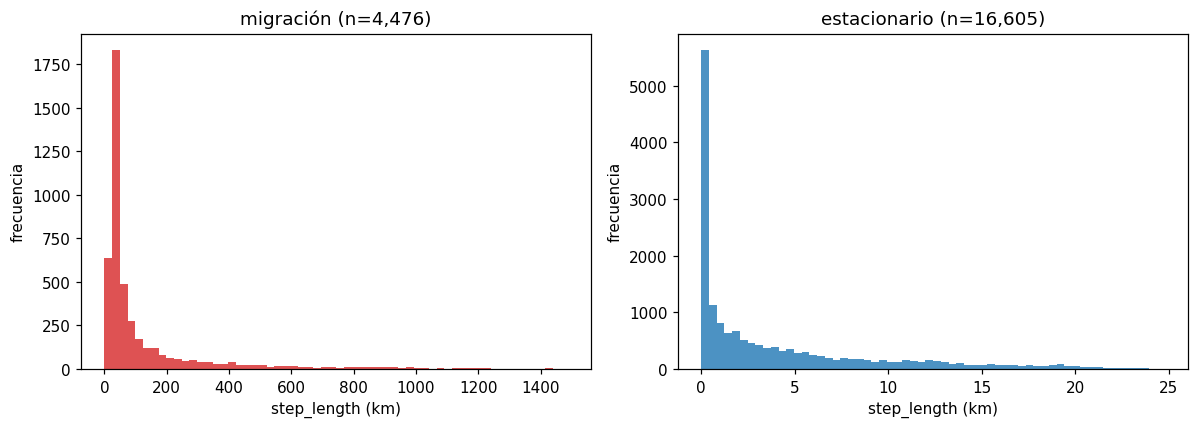

In [13]:
# 7.3 — Histogramas de step_length por estado
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for state, name, ax, color in [(0, 'migración', axes[0], 'tab:red'),
                                (1, 'estacionario', axes[1], 'tab:blue')]:
    sub = df_hmm.loc[df_hmm['estado_hmm'] == state, 'step_length']
    ax.hist(sub, bins=60, color=color, alpha=0.8)
    ax.set_title(f'{name} (n={len(sub):,})')
    ax.set_xlabel('step_length (km)')
    ax.set_ylabel('frecuencia')
plt.tight_layout()
plt.show()

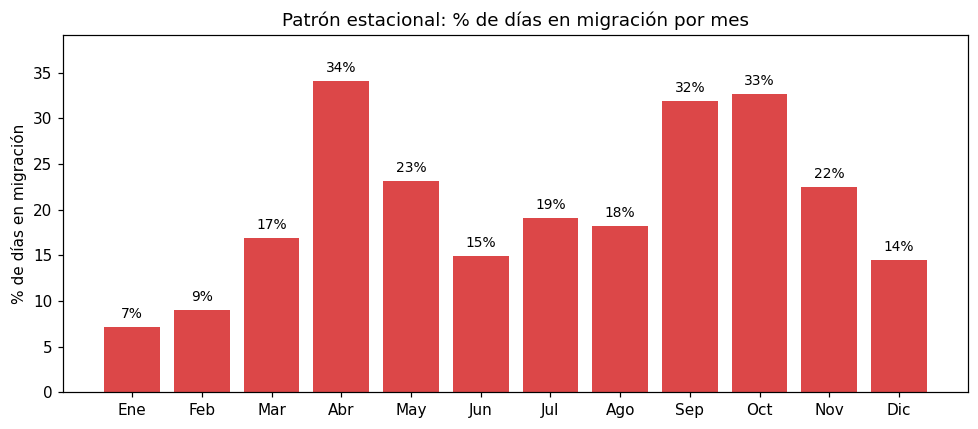


% de días en migración por mes:
mes
1     7.1000
2     9.0000
3    16.9000
4    34.0000
5    23.1000
6    14.9000
7    19.1000
8    18.2000
9    31.9000
10   32.7000
11   22.5000
12   14.5000
Name: estado_hmm, dtype: float64


In [14]:
# 7.4 — Patrón estacional: % de días en migración por mes
df_hmm['mes'] = df_hmm['date'].dt.month
pct_mig = df_hmm.groupby('mes')['estado_hmm'].apply(lambda s: (s == 0).mean() * 100)
nombres = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
           'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(nombres, pct_mig.values, color='tab:red', alpha=0.85)
ax.set_ylabel('% de días en migración')
ax.set_title('Patrón estacional: % de días en migración por mes')
ax.set_ylim(0, max(pct_mig.values) * 1.15)
for i, v in enumerate(pct_mig.values):
    ax.text(i, v + 1, f'{v:.0f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\n% de días en migración por mes:')
print(pct_mig.round(1))

Ave ejemplo: 91916A (2026 días)


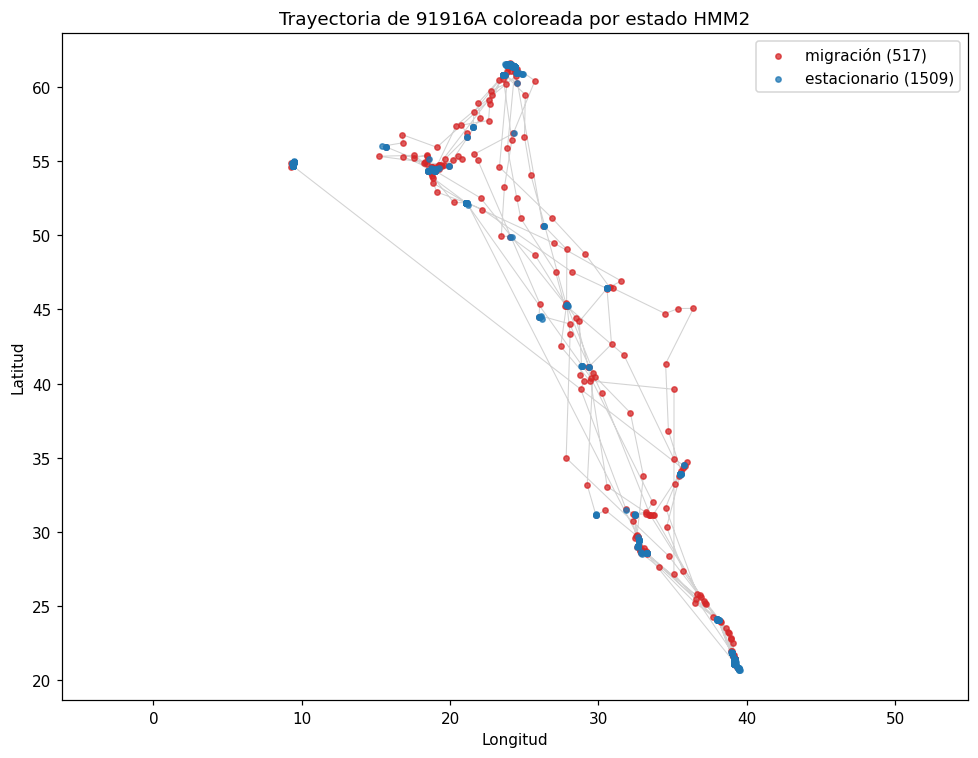

In [15]:
# 7.5 — Trayectoria de un ave coloreada por estado
ave_ej = df_hmm['animal_id'].value_counts().index[0]
sub = df_hmm[df_hmm['animal_id'] == ave_ej].sort_values('date')
print(f'Ave ejemplo: {ave_ej} ({len(sub)} días)')

fig, ax = plt.subplots(figsize=(9, 7))
ax.plot(sub['lon'], sub['lat'], color='lightgray', linewidth=0.7, zorder=1)
for state, name, color in [(0, 'migración', 'tab:red'), (1, 'estacionario', 'tab:blue')]:
    pts = sub[sub['estado_hmm'] == state]
    ax.scatter(pts['lon'], pts['lat'], s=12, c=color, label=f'{name} ({len(pts)})',
               alpha=0.75, zorder=2)
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.set_title(f'Trayectoria de {ave_ej} coloreada por estado HMM2')
ax.legend()
ax.set_aspect('equal', adjustable='datalim')
plt.tight_layout()
plt.show()

## 8. Resumen comparativo HMM2 vs HMM1

Imprimimos lado a lado las métricas clave de HMM2 (este notebook) con los valores conocidos del HMM1 (reportados a partir de inspección del notebook original).

In [16]:
# Valores reportados de HMM1 (extraídos de notebooks/HMM.ipynb tras su ejecución)
hmm1_step_mean_mig = 119.87
hmm1_step_mean_est = 3.90

comp = pd.DataFrame({
    'HMM1 (notebooks/HMM.ipynb)': [
        f'{hmm1_step_mean_mig:.2f}',
        f'{hmm1_step_mean_est:.2f}',
        'no calculada',
        'no calculado',
        'no medido',
        'No (~480 transiciones espurias)',
        'step_length, turning_angle, veg_low, veg_high',
        'Ninguna',
        'No',
        'Manual, post-hoc',
    ],
    'HMM2 v2 (este notebook)': [
        f'{stats.loc["migración (0)", "step_mean_km"]:.2f}',
        f'{stats.loc["estacionario (1)", "step_mean_km"]:.2f}',
        f'mig {mean_dur_mig:.2f} d / est {mean_dur_est:.2f} d',
        f'p_diag mig {T[0,0]:.3f} / est {T[1,1]:.3f}',
        'medido (gráfica % migración por mes)',
        'Sí — lengths= por trayectoria_id',
        'step_length (km), cos(turning_angle)',
        'Ninguna (varianza natural domina)',
        'Sí (15 random_states)',
        'Automática por means_',
    ],
}, index=[
    'Media step_length migración (km)',
    'Media step_length estacionario (km)',
    'Duración media por estado',
    'Persistencia diagonal',
    'Patrón estacional',
    'Separación de secuencias',
    'Features observadas',
    'Estandarización',
    'Múltiples inicializaciones',
    'Asignación 0/1',
])
comp

,HMM1 (notebooks/HMM.ipynb),HMM2 v2 (este notebook)
Media step_length migración (km),119.87,129.57
Media step_length estacionario (km),3.90,4.09
Duración media por estado,no calculada,mig 3.41 d / est 12.10 d
Persistencia diagonal,no calculado,p_diag mig 0.706 / est 0.917
Patrón estacional,no medido,medido (gráfica % migración por mes)
Separación de secuencias,No (~480 transiciones espurias),Sí — lengths= por trayectoria_id
Features observadas,"step_length, turning_angle, veg_low, veg_high","step_length (km), cos(turning_angle)"
Estandarización,Ninguna,Ninguna (varianza natural domina)
Múltiples inicializaciones,No,Sí (15 random_states)
Asignación 0/1,"Manual, post-hoc",Automática por means_


## Conclusión

El HMM2 mantiene la separación intuitiva de los dos modos en `step_length` (medias muy distintas para migración y estacionario, igual que HMM1) pero **arregla los problemas de la dinámica temporal**:

- La matriz de transición refleja transiciones reales **dentro** de cada `trayectoria_id`, sin contaminación entre secuencias.
- La duración media por estado se puede leer directamente como `1 / (1 - p_diag)` de forma fiable.
- El patrón estacional confirma comportamiento físico esperado (picos de migración en primavera/otoño).
- La asignación de etiquetas es invariante al `random_state` y a la inicialización del EM.
- El diseño es fiel al enunciado de la profesora (solo velocidad y rumbo).